# PINN for the Damped Harmonic Oscillator
ML4Sci — PINNDE Test Task

Test statement: solve the damped harmonic oscillator differential equation using a Physics-Informed Neural Network (PINN)

$$\frac{d^2 x}{dz^2} + 2\xi\frac{dx}{dz} + x = 0, \quad x(0)=0.7,\; \dot{x}(0)=1.2, \quad z\in[0,20],\; \xi\in[0.1,0.4]$$

Setup: run from the repo root. If needed, install dependencies with

```bash
pip install -r requirements.txt
```


In [3]:
import torch, numpy as np, matplotlib.pyplot as plt
from utils import PINN, train, error_table, errors, plot_losses, plot_solutions, \
                  plot_residual_heatmap, plot_phase, make_gif, analytical, physics_loss, ic_loss

torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


## Baseline (tanh)

In [14]:
model = PINN(hidden=64, layers=4, act='tanh').to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
history = train(model, device, epochs=50000)

Parameters: 16,897


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch  5000/50000 | Total: 0.012702 | Phys: 0.007535 | IC: 0.000103
Epoch 10000/50000 | Total: 0.016845 | Phys: 0.005036 | IC: 0.000236
Epoch 15000/50000 | Total: 0.003576 | Phys: 0.003527 | IC: 0.000001
Epoch 20000/50000 | Total: 0.002887 | Phys: 0.002807 | IC: 0.000002
Epoch 25000/50000 | Total: 0.002717 | Phys: 0.002365 | IC: 0.000007
Epoch 30000/50000 | Total: 0.001952 | Phys: 0.001847 | IC: 0.000002
Epoch 35000/50000 | Total: 0.001301 | Phys: 0.001149 | IC: 0.000003
Epoch 40000/50000 | Total: 0.000945 | Phys: 0.000937 | IC: 0.000000
Epoch 45000/50000 | Total: 0.000596 | Phys: 0.000594 | IC: 0.000000
Epoch 50000/50000 | Total: 0.000664 | Phys: 0.000663 | IC: 0.000000


PINNs compute d²x/dz² via autograd, so we need an activation that is smooth (C∞). ReLU fails here because its 2nd derivative is zero everywhere. I know that tanh is the standard PINN choice: smooth, bounded, well-behaved gradients.

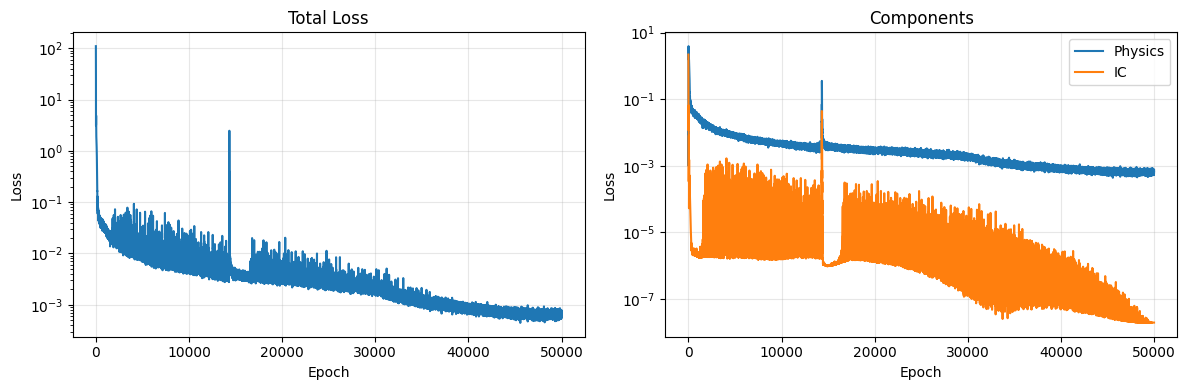

In [15]:
plot_losses(history)

In [16]:
error_table(model, device)

     ξ |         L2 |        Max |   Rel L2
--------------------------------------------
  0.10 |   1.91e-01 |   3.71e-01 |   36.03%
  0.15 |   9.05e-02 |   1.76e-01 |   19.93%
  0.20 |   3.66e-02 |   6.98e-02 |    8.94%
  0.25 |   1.08e-02 |   2.21e-02 |    2.83%
  0.30 |   1.29e-02 |   3.58e-02 |    3.59%
  0.35 |   1.94e-02 |   5.06e-02 |    5.62%
  0.40 |   2.39e-02 |   5.40e-02 |    7.14%


{0.1: {'L2': np.float64(0.19088302786792952),
  'Max': np.float64(0.37076421660795955),
  'Rel_L2': np.float64(0.36026095931968616)},
 0.15: {'L2': np.float64(0.09049241611687235),
  'Max': np.float64(0.1763243759596687),
  'Rel_L2': np.float64(0.1993359793053994)},
 0.2: {'L2': np.float64(0.03661629228321776),
  'Max': np.float64(0.06982020285065973),
  'Rel_L2': np.float64(0.08943787416899103)},
 0.25: {'L2': np.float64(0.010757228212324815),
  'Max': np.float64(0.02212280674963237),
  'Rel_L2': np.float64(0.028268634713137855)},
 0.3: {'L2': np.float64(0.012943742081417412),
  'Max': np.float64(0.03581323673059105),
  'Rel_L2': np.float64(0.03590154587535039)},
 0.35: {'L2': np.float64(0.01944416420101793),
  'Max': np.float64(0.05061047611962062),
  'Rel_L2': np.float64(0.056190612141294366)},
 0.4: {'L2': np.float64(0.02392661440413708),
  'Max': np.float64(0.054012951876747095),
  'Rel_L2': np.float64(0.07137757390669132)}}

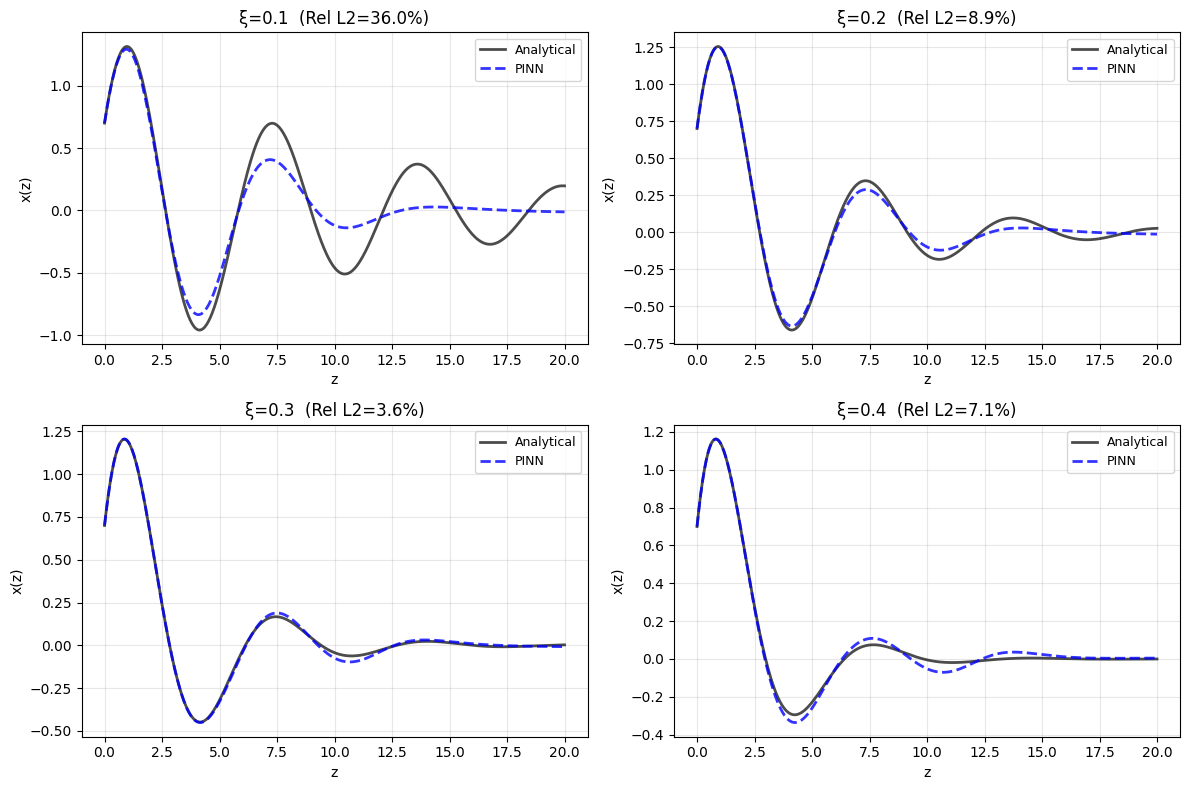

In [17]:
plot_solutions(model, device)

## Fourier features
Low ξ → more oscillations → harder for plain MLPs (spectral bias). Fourier features give the network direct access to high-frequency basis functions.

In [18]:
model_ff = PINN(hidden=64, layers=4, act='tanh', fourier=64, sigma=1.0).to(device)
print(f"Parameters: {sum(p.numel() for p in model_ff.parameters()):,}")
history_ff = train(model_ff, device, epochs=50000)

Parameters: 25,089
Epoch  5000/50000 | Total: 0.006058 | Phys: 0.005260 | IC: 0.000016
Epoch 10000/50000 | Total: 0.006127 | Phys: 0.005854 | IC: 0.000005
Epoch 15000/50000 | Total: 0.005095 | Phys: 0.005081 | IC: 0.000000
Epoch 20000/50000 | Total: 0.009502 | Phys: 0.004370 | IC: 0.000103
Epoch 25000/50000 | Total: 0.003991 | Phys: 0.003909 | IC: 0.000002
Epoch 30000/50000 | Total: 0.002725 | Phys: 0.002475 | IC: 0.000005
Epoch 35000/50000 | Total: 0.001848 | Phys: 0.001748 | IC: 0.000002
Epoch 40000/50000 | Total: 0.001135 | Phys: 0.001115 | IC: 0.000000
Epoch 45000/50000 | Total: 0.000590 | Phys: 0.000589 | IC: 0.000000
Epoch 50000/50000 | Total: 0.000630 | Phys: 0.000629 | IC: 0.000000


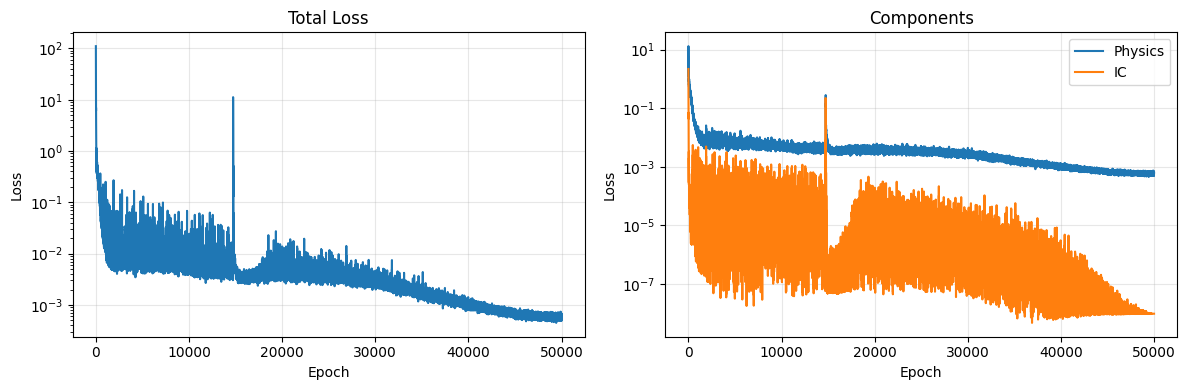

In [19]:
plot_losses(history_ff)

In [20]:
error_table(model_ff, device)

     ξ |         L2 |        Max |   Rel L2
--------------------------------------------
  0.10 |   1.63e-01 |   2.93e-01 |   30.79%
  0.15 |   7.16e-02 |   1.30e-01 |   15.78%
  0.20 |   2.31e-02 |   4.19e-02 |    5.64%
  0.25 |   6.43e-03 |   1.40e-02 |    1.69%
  0.30 |   2.01e-02 |   4.87e-02 |    5.59%
  0.35 |   2.89e-02 |   6.93e-02 |    8.36%
  0.40 |   3.46e-02 |   8.05e-02 |   10.33%


{0.1: {'L2': np.float64(0.16313898704189547),
  'Max': np.float64(0.2932080839547043),
  'Rel_L2': np.float64(0.30789855248324866)},
 0.15: {'L2': np.float64(0.0716388878444561),
  'Max': np.float64(0.13044930801919746),
  'Rel_L2': np.float64(0.15780557617536944)},
 0.2: {'L2': np.float64(0.02307166180800604),
  'Max': np.float64(0.04192380087479197),
  'Rel_L2': np.float64(0.05635415977383678)},
 0.25: {'L2': np.float64(0.006431298306399025),
  'Max': np.float64(0.013997848154762071),
  'Rel_L2': np.float64(0.016900638246804038)},
 0.3: {'L2': np.float64(0.02013971218921502),
  'Max': np.float64(0.04870280483974898),
  'Rel_L2': np.float64(0.05586072377906025)},
 0.35: {'L2': np.float64(0.028925577137454007),
  'Max': np.float64(0.06934329050103077),
  'Rel_L2': np.float64(0.08359042173737045)},
 0.4: {'L2': np.float64(0.03461564763925676),
  'Max': np.float64(0.0805041659441254),
  'Rel_L2': np.float64(0.10326496285541421)}}

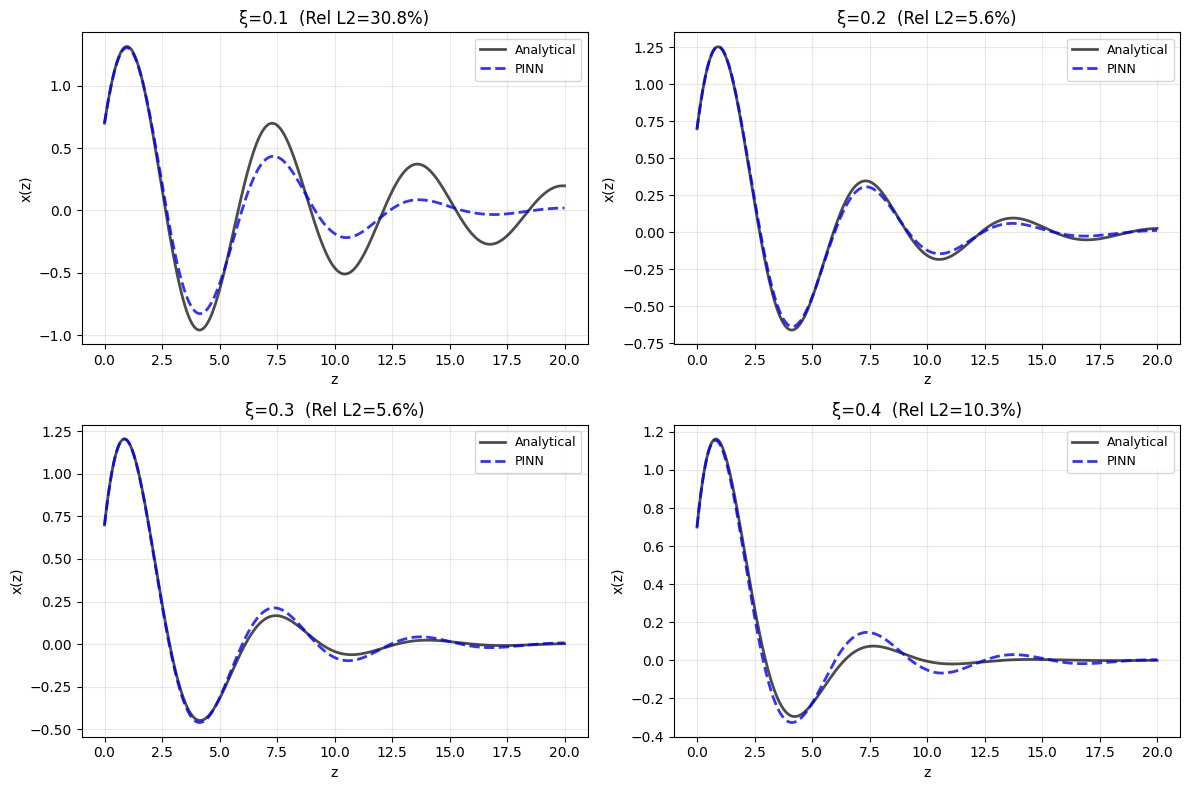

In [21]:
plot_solutions(model_ff, device)

## Activation ablation
Quick comparison of tanh vs sin vs GELU (all with Fourier features).

In [22]:
results = {}
for act in ['tanh', 'sin', 'gelu']:
    print(f"\n--- {act} ---")
    m = PINN(hidden=64, layers=4, act=act, fourier=64, sigma=1.0).to(device)
    torch.manual_seed(42)
    train(m, device, epochs=50000, print_every=5000)
    results[act] = error_table(m, device, xi_list=[0.1, 0.2, 0.3, 0.4])


--- tanh ---
Epoch  5000/50000 | Total: 0.006349 | Phys: 0.005885 | IC: 0.000009
Epoch 10000/50000 | Total: 0.005503 | Phys: 0.005097 | IC: 0.000008
Epoch 15000/50000 | Total: 0.003688 | Phys: 0.003669 | IC: 0.000000
Epoch 20000/50000 | Total: 0.004210 | Phys: 0.004100 | IC: 0.000002
Epoch 25000/50000 | Total: 0.003487 | Phys: 0.003184 | IC: 0.000006
Epoch 30000/50000 | Total: 0.002812 | Phys: 0.002646 | IC: 0.000003
Epoch 35000/50000 | Total: 0.002127 | Phys: 0.001520 | IC: 0.000012
Epoch 40000/50000 | Total: 0.000875 | Phys: 0.000873 | IC: 0.000000
Epoch 45000/50000 | Total: 0.000393 | Phys: 0.000390 | IC: 0.000000
Epoch 50000/50000 | Total: 0.000359 | Phys: 0.000357 | IC: 0.000000
     ξ |         L2 |        Max |   Rel L2
--------------------------------------------
  0.10 |   1.39e-01 |   2.55e-01 |   26.31%
  0.20 |   1.51e-02 |   2.63e-02 |    3.69%
  0.30 |   1.60e-02 |   3.60e-02 |    4.44%
  0.40 |   2.25e-02 |   4.52e-02 |    6.72%

--- sin ---
Epoch  5000/50000 | Total: 0

In [23]:
print("\nSummary — Relative L2 (%)")
print(f"{'act':>8} | {'ξ=0.1':>7} | {'ξ=0.2':>7} | {'ξ=0.3':>7} | {'ξ=0.4':>7}")
print("-"*46)
for act, r in results.items():
    v = [f"{r[xi]['Rel_L2']*100:6.1f}%" for xi in [0.1, 0.2, 0.3, 0.4]]
    print(f"{act:>8} | {' | '.join(v)}")


Summary — Relative L2 (%)
     act |   ξ=0.1 |   ξ=0.2 |   ξ=0.3 |   ξ=0.4
----------------------------------------------
    tanh |   26.3% |    3.7% |    4.4% |    6.7%
     sin |   29.7% |    5.3% |    4.6% |    8.4%
    gelu |    9.5% |    2.2% |    1.0% |    2.0%


GELU is consistently the most accurate across ξ in this run, so it is used for diagnostics.


## Diagnostics

In [4]:
# evaluate best config: GELU + Fourier features
best = PINN(hidden=64, layers=4, act='gelu', fourier=64, sigma=1.0).to(device)
torch.manual_seed(42)
train(best, device, epochs=50000)
error_table(best, device)

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch  5000/50000 | Total: 0.003552 | Phys: 0.003448 | IC: 0.000002
Epoch 10000/50000 | Total: 0.006639 | Phys: 0.004025 | IC: 0.000052
Epoch 15000/50000 | Total: 0.004227 | Phys: 0.003247 | IC: 0.000020
Epoch 20000/50000 | Total: 0.001952 | Phys: 0.001875 | IC: 0.000002
Epoch 25000/50000 | Total: 0.000416 | Phys: 0.000403 | IC: 0.000000
Epoch 30000/50000 | Total: 0.000188 | Phys: 0.000178 | IC: 0.000000
Epoch 35000/50000 | Total: 0.000155 | Phys: 0.000149 | IC: 0.000000
Epoch 40000/50000 | Total: 0.000074 | Phys: 0.000071 | IC: 0.000000
Epoch 45000/50000 | Total: 0.000034 | Phys: 0.000034 | IC: 0.000000
Epoch 50000/50000 | Total: 0.000029 | Phys: 0.000029 | IC: 0.000000
     ξ |         L2 |        Max |   Rel L2
--------------------------------------------
  0.10 |   5.03e-02 |   8.65e-02 |    9.49%
  0.15 |   3.88e-03 |   8.48e-03 |    0.85%
  0.20 |   9.02e-03 |   1.54e-02 |    2.20%
  0.25 |   6.90e-03 |   1.12e-02 |    1.81%
  0.30 |   3.72e-03 |   9.32e-03 |    1.03%
  0.35 |   

{0.1: {'L2': np.float64(0.05027385627166525),
  'Max': np.float64(0.08646906037658403),
  'Rel_L2': np.float64(0.09488380340268644)},
 0.15: {'L2': np.float64(0.003881333736101397),
  'Max': np.float64(0.008475344632480009),
  'Rel_L2': np.float64(0.008549771290199884)},
 0.2: {'L2': np.float64(0.009018618485715005),
  'Max': np.float64(0.015352507889198674),
  'Rel_L2': np.float64(0.02202861117298882)},
 0.25: {'L2': np.float64(0.00690172114477925),
  'Max': np.float64(0.011177021999654008),
  'Rel_L2': np.float64(0.018136849947105422)},
 0.3: {'L2': np.float64(0.0037152948105610346),
  'Max': np.float64(0.009322956817819694),
  'Rel_L2': np.float64(0.010304966387834716)},
 0.35: {'L2': np.float64(0.0028159309621712232),
  'Max': np.float64(0.0059899709277695876),
  'Rel_L2': np.float64(0.008137602772545067)},
 0.4: {'L2': np.float64(0.006794076173255468),
  'Max': np.float64(0.01673413210437613),
  'Rel_L2': np.float64(0.020268002233545516)}}

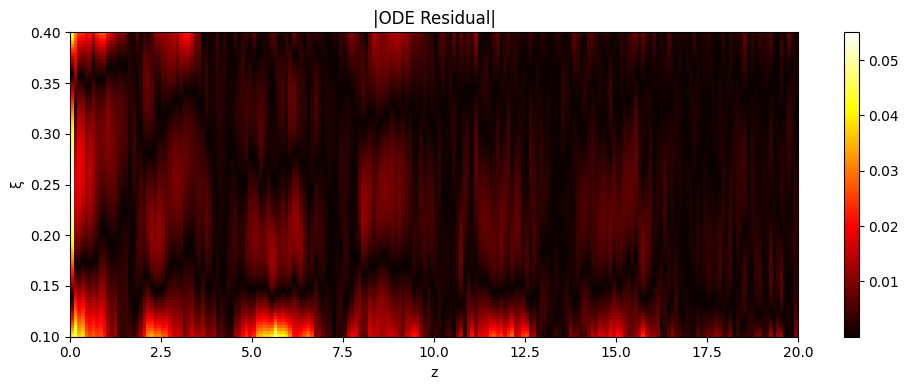

In [7]:
plot_residual_heatmap(best, device)

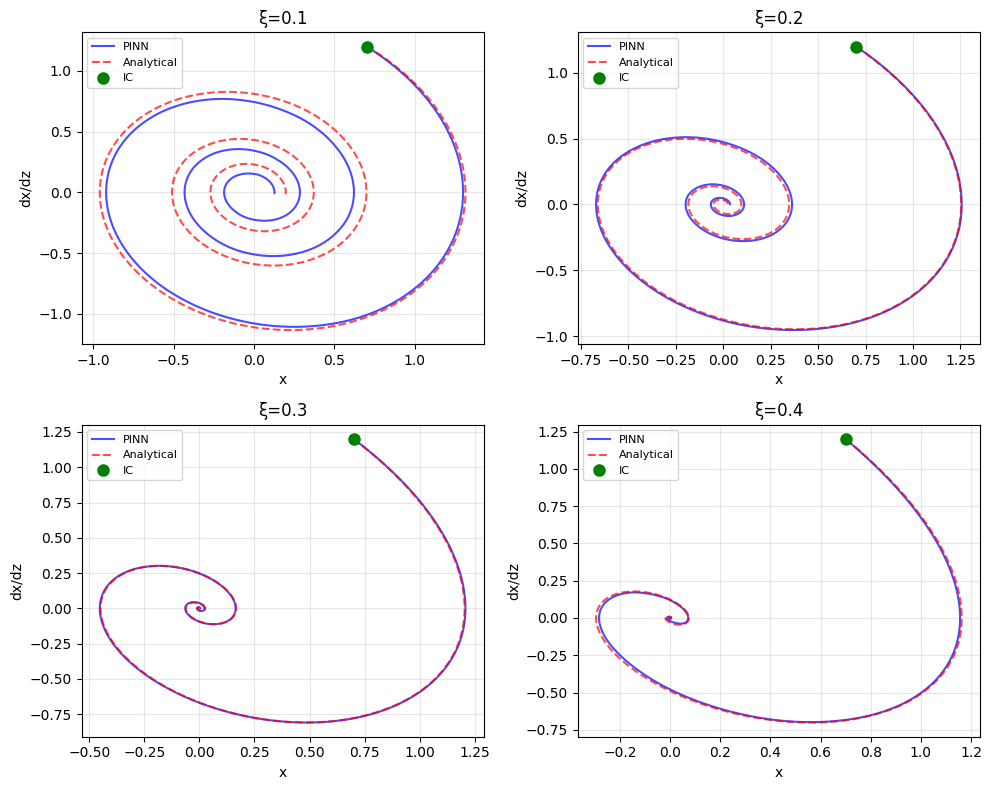

In [8]:
plot_phase(best, device)

## Generalization (unseen ξ)

In [26]:
error_table(best, device, xi_list=[0.12, 0.18, 0.27, 0.33, 0.38])

     ξ |         L2 |        Max |   Rel L2
--------------------------------------------
  0.12 |   1.19e-01 |   2.17e-01 |   24.15%
  0.18 |   3.90e-02 |   7.24e-02 |    9.17%
  0.27 |   1.24e-02 |   2.99e-02 |    3.34%
  0.33 |   2.59e-02 |   6.24e-02 |    7.37%
  0.38 |   3.26e-02 |   7.70e-02 |    9.61%


{0.12: {'L2': np.float64(0.11933610144065965),
  'Max': np.float64(0.21705565302932933),
  'Rel_L2': np.float64(0.24154966281181253)},
 0.18: {'L2': np.float64(0.038959080482031595),
  'Max': np.float64(0.07240124036686446),
  'Rel_L2': np.float64(0.0917195292562431)},
 0.27: {'L2': np.float64(0.01240646172536597),
  'Max': np.float64(0.029949535147390516),
  'Rel_L2': np.float64(0.033376925755896764)},
 0.33: {'L2': np.float64(0.025907222512342707),
  'Max': np.float64(0.06243343978591018),
  'Rel_L2': np.float64(0.07374327483368465)},
 0.38: {'L2': np.float64(0.03258333365122523),
  'Max': np.float64(0.07696189406518544),
  'Rel_L2': np.float64(0.09606379575750991)}}

## GIF

In [9]:
make_gif(best, device)

Saved: figures/sweep.gif


In [10]:
def make_training_gif(device, path='figures/training.gif', xi_val=0.2, fps=15):
    """Watch the PINN learn over training epochs."""
    model = PINN(hidden=64, layers=4, act='gelu', fourier=64, sigma=1.0).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50000)

    z_plot = torch.linspace(0, 20, 500, device=device).reshape(-1,1)
    z_np = z_plot.cpu().numpy().flatten()
    true = analytical(z_np, xi_val)

    tmpdir = tempfile.mkdtemp()
    files = []

    for ep in range(50000):
        z  = torch.rand(1000, 1, device=device) * 20.0
        xi = torch.rand(1000, 1, device=device) * 0.3 + 0.1
        opt.zero_grad()
        lp = physics_loss(model, z, xi)
        li = ic_loss(model, device)
        (lp + 50*li).backward()
        opt.step(); sched.step()

        if (ep+1) % 500 == 0:
            with torch.no_grad():
                pred = model(z_plot, torch.ones_like(z_plot)*xi_val).cpu().numpy().flatten()
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(z_np, true, 'k-', lw=2, label='Analytical', alpha=.7)
            ax.plot(z_np, pred, 'b-', lw=2, label='PINN', alpha=.8)
            ax.set(xlabel='z', ylabel='x(z)', xlim=(0,20), ylim=(-1.5,1.5),
                   title=f'PINN Training — Epoch {ep+1}')
            ax.legend(loc='upper right'); ax.grid(alpha=.3)
            f = os.path.join(tmpdir, f'{ep:06d}.png')
            fig.savefig(f, dpi=100, bbox_inches='tight', facecolor='white')
            files.append(f); plt.close(fig)

    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    imgs = [Image.open(f) for f in files]
    imgs[0].save(path, format='GIF', append_images=imgs[1:],
                 save_all=True, duration=int(1000/fps), loop=0)
    for f in files: os.remove(f)
    print(f"Saved: {path}")

In [11]:
make_training_gif(device)

NameError: name 'analytical' is not defined

## Save

In [ ]:
torch.save(best.state_dict(), 'best_model.pt')
print("Saved.")